In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

Predict delivery time using order, restaurant, and partner data

In [62]:
df=pd.read_csv('porter.csv')
df.head(5)

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,f0ade77b43923b38237db569b016ba25,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,f0ade77b43923b38237db569b016ba25,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,f0ade77b43923b38237db569b016ba25,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,f0ade77b43923b38237db569b016ba25,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   market_id                 196441 non-null  float64
 1   created_at                197428 non-null  object 
 2   actual_delivery_time      197421 non-null  object 
 3   store_id                  197428 non-null  object 
 4   store_primary_category    192668 non-null  object 
 5   order_protocol            196433 non-null  float64
 6   total_items               197428 non-null  int64  
 7   subtotal                  197428 non-null  int64  
 8   num_distinct_items        197428 non-null  int64  
 9   min_item_price            197428 non-null  int64  
 10  max_item_price            197428 non-null  int64  
 11  total_onshift_partners    181166 non-null  float64
 12  total_busy_partners       181166 non-null  float64
 13  total_outstanding_orders  181166 non-null  f

In [64]:
df.describe()

,market_id,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
count,196441.000000,196433.000000,197428.000000,197428.000000,197428.000000,197428.000000,197428.000000,181166.000000,181166.000000,181166.000000
mean,2.978706,2.882352,3.196391,2682.331402,2.670791,686.218470,1159.588630,44.808093,41.739747,58.050065
std,1.524867,1.503771,2.666546,1823.093688,1.630255,522.038648,558.411377,34.526783,32.145733,52.661830
min,1.000000,1.000000,1.000000,0.000000,1.000000,-86.000000,0.000000,-4.000000,-5.000000,-6.000000
25%,2.000000,1.000000,2.000000,1400.000000,1.000000,299.000000,800.000000,17.000000,15.000000,17.000000
50%,3.000000,3.000000,3.000000,2200.000000,2.000000,595.000000,1095.000000,37.000000,34.000000,41.000000
75%,4.000000,4.000000,4.000000,3395.000000,3.000000,949.000000,1395.000000,65.000000,62.000000,85.000000
max,6.000000,7.000000,411.000000,27100.000000,20.000000,14700.000000,14700.000000,171.000000,154.000000,285.000000


In [65]:
df.shape

(197428, 14)

The dataset contains ~197K rows and multiple features related to orders, restaurants, and delivery partners.

In [66]:
df.isna().count()

market_id                   197428
created_at                  197428
actual_delivery_time        197428
store_id                    197428
store_primary_category      197428
order_protocol              197428
total_items                 197428
subtotal                    197428
num_distinct_items          197428
min_item_price              197428
max_item_price              197428
total_onshift_partners      197428
total_busy_partners         197428
total_outstanding_orders    197428
dtype: int64

Numerical features: subtotal, total_items, partner-related columns
Categorical features: store_primary_category, order_protocol, market_id
Timestamp features: created_at, actual_delivery_time

In [67]:
df = df.dropna(subset=['actual_delivery_time'])

In [68]:
df['store_primary_category'] = df['store_primary_category'].fillna("Unknown")

df['order_protocol'] = df['order_protocol'].fillna(df['order_protocol'].mode()[0])

df['market_id'] = df['market_id'].fillna(df['market_id'].mode()[0])

In [69]:
# numerical
df['total_onshift_partners'].fillna(df['total_onshift_partners'].median(), )
df['total_busy_partners'].fillna(df['total_busy_partners'].median(), )
df['total_outstanding_orders'].fillna(df['total_outstanding_orders'].median(),)

0         21.0
1          2.0
2          0.0
3          2.0
4          9.0
          ... 
197423    23.0
197424    14.0
197425    40.0
197426    12.0
197427    23.0
Name: total_outstanding_orders, Length: 197421, dtype: float64

Missing values were present in multiple columns, especially in partner-related features (~16K missing values), which were handled using median and mode imputation.

Instead of using inplace operations on column slices, we reassigned the filled values back to the dataframe to avoid chained assignment issues.

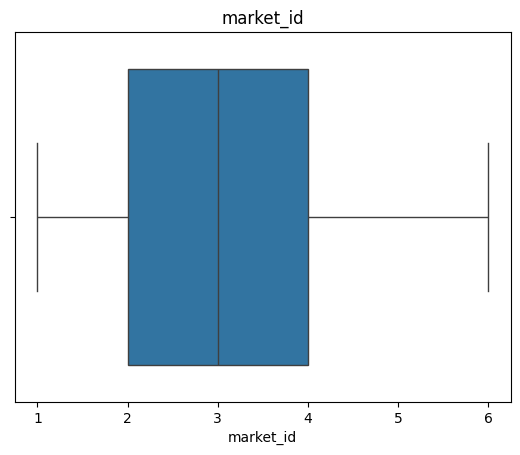

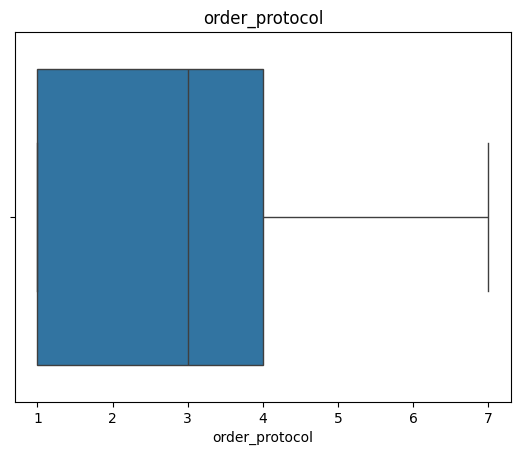

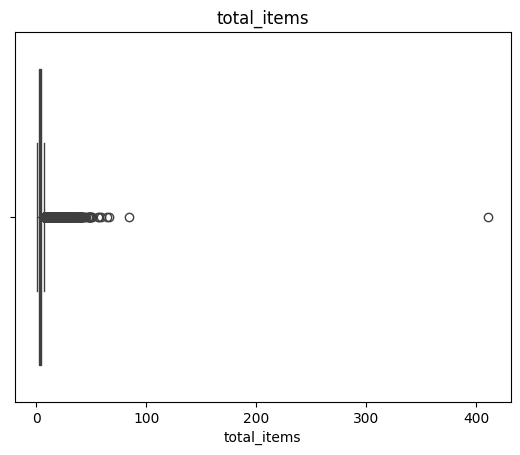

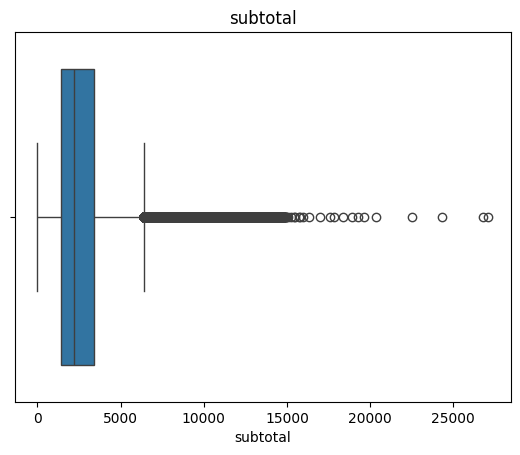

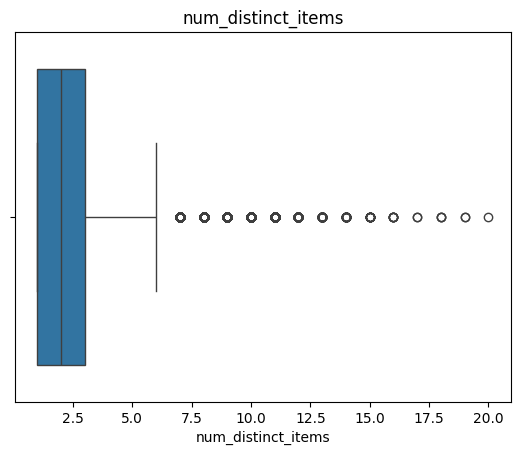

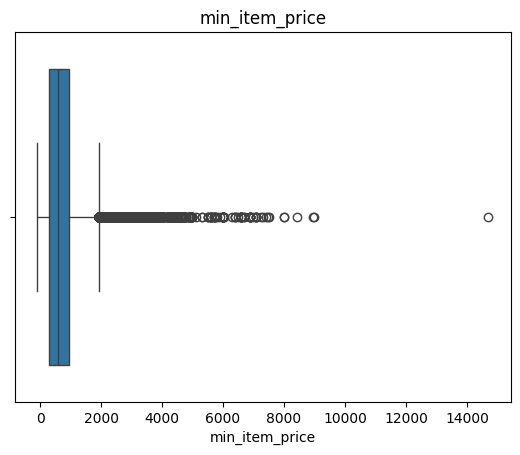

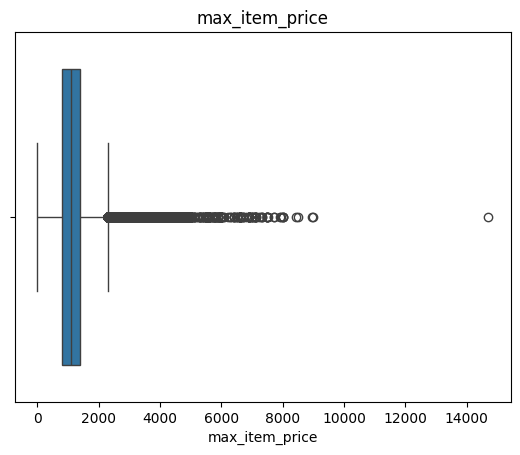

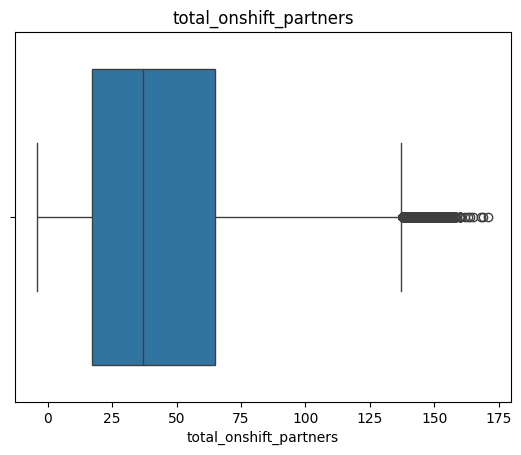

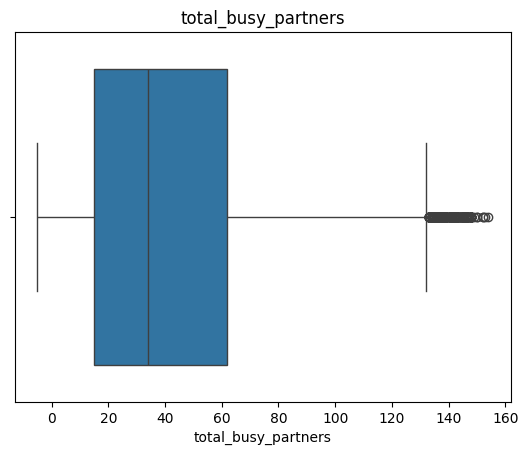

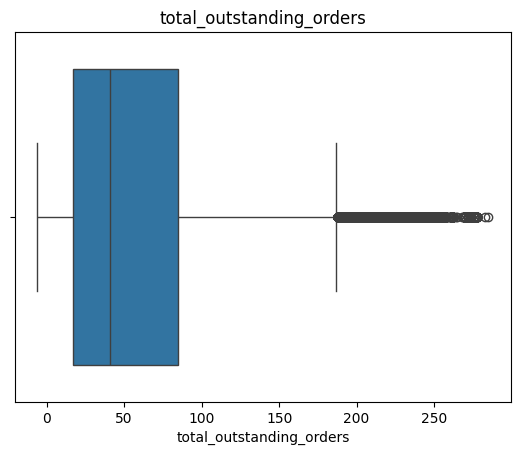

In [70]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

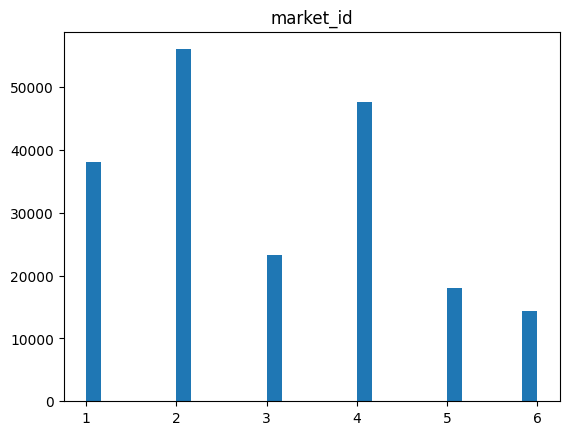

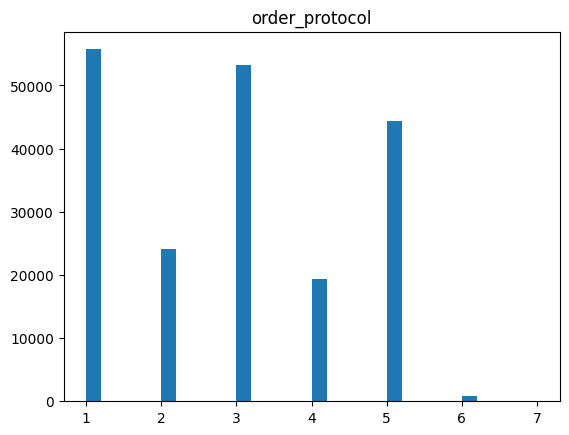

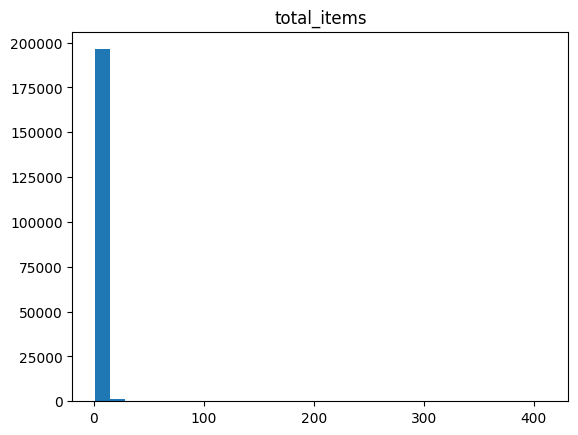

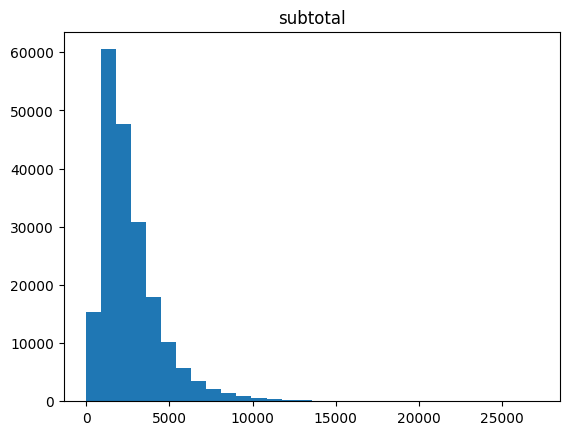

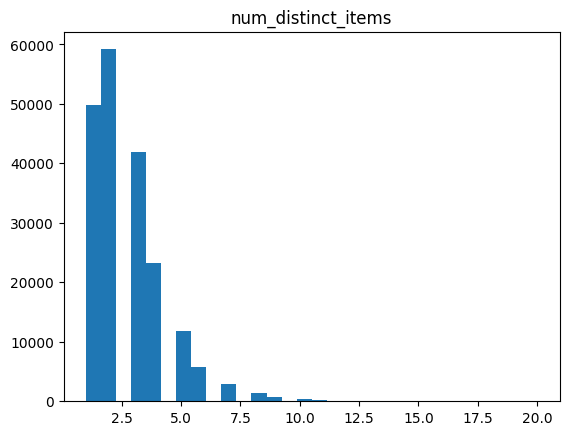

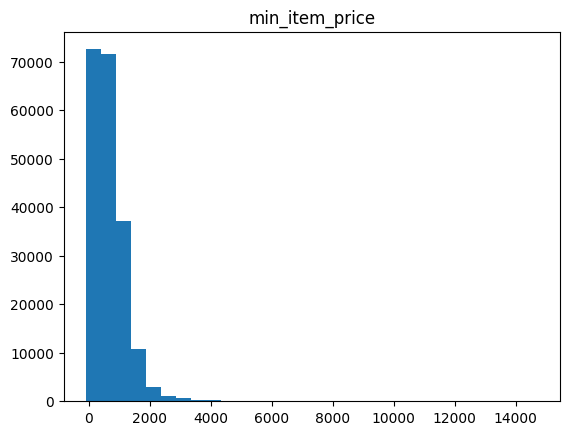

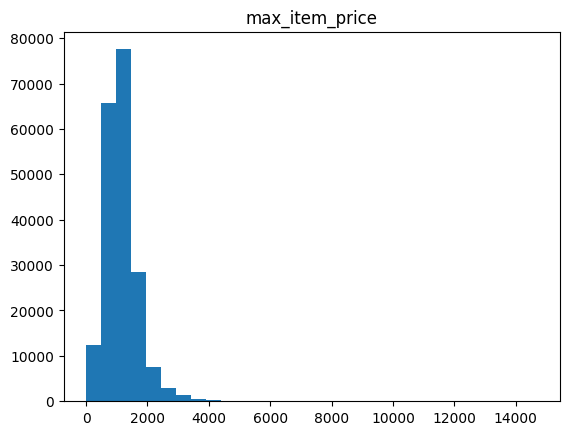

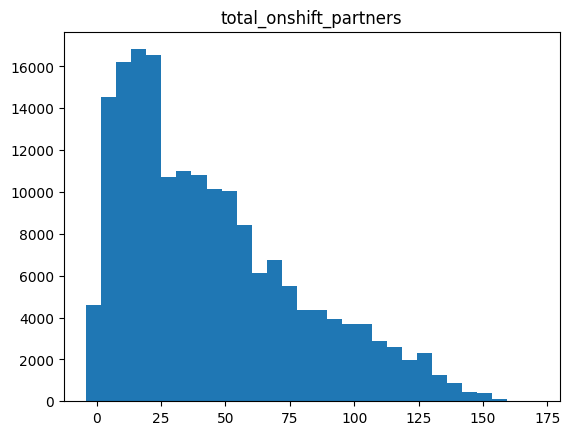

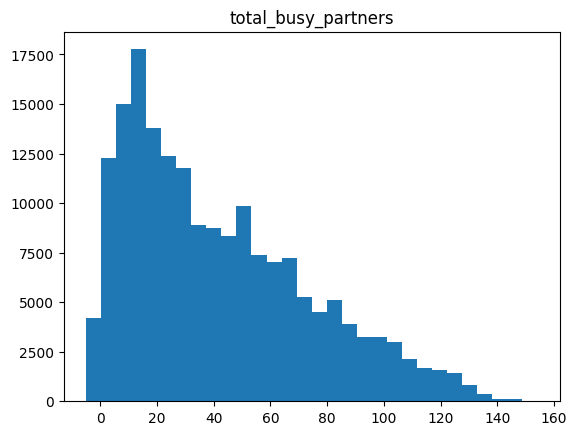

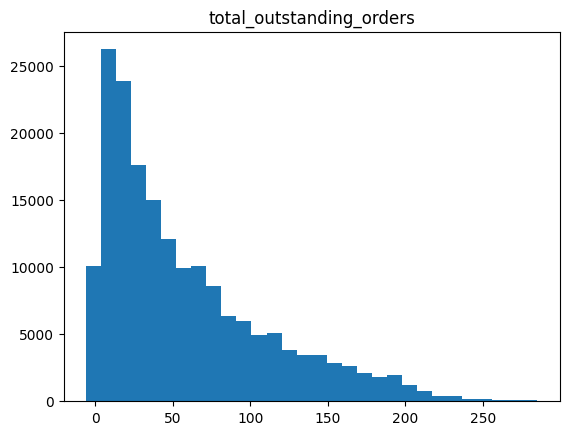

In [71]:
for col in num_cols:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(col)
    plt.show()

Outliers were detected in price and item-related features and handled using IQR method.

In [72]:
cols = ['subtotal', 'total_items', 'min_item_price','total_outstanding_orders','total_busy_partners','total_onshift_partners','max_item_price','num_distinct_items']
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

Outliers were handled using the IQR method. Instead of aggressively 
removing rows, we also used capping (clipping) to limit extreme values and preserve data.

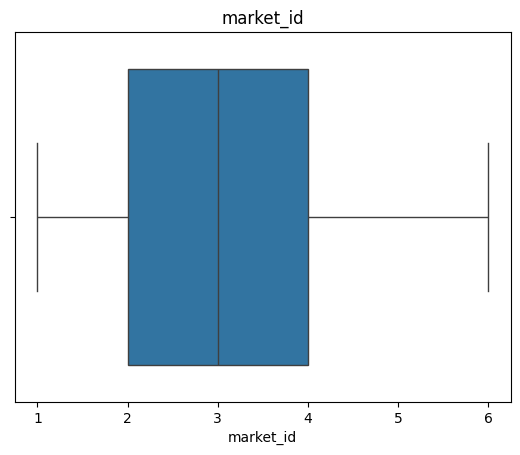

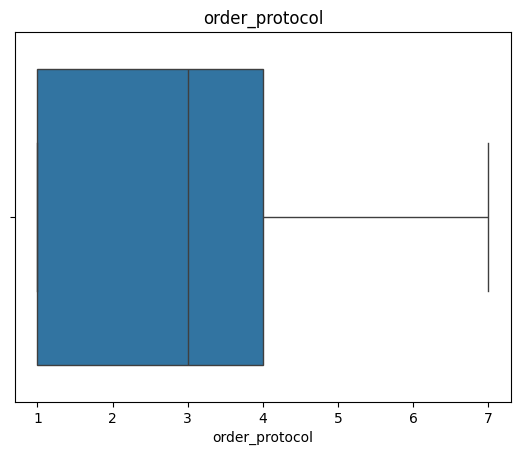

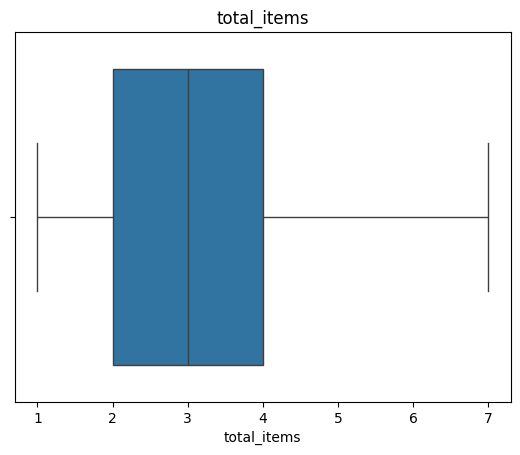

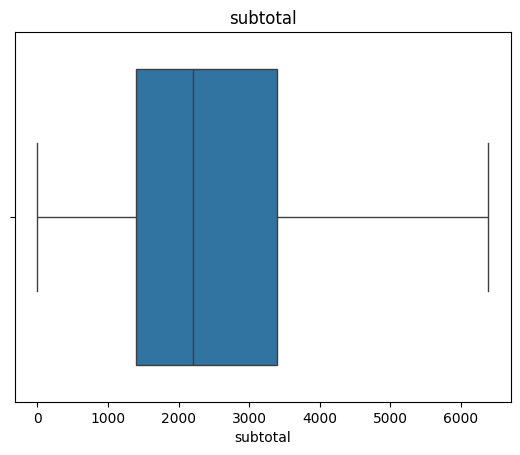

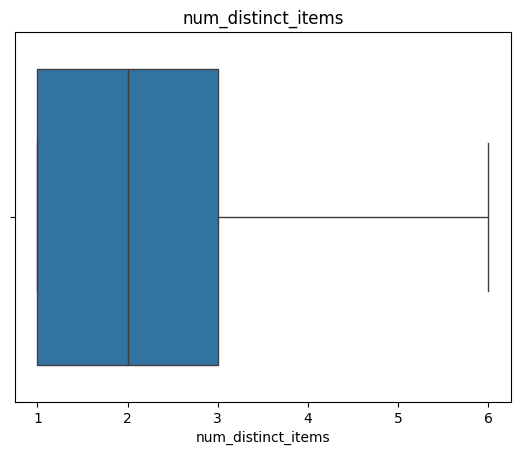

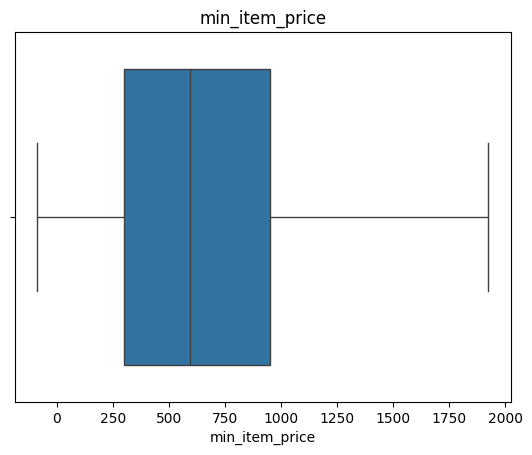

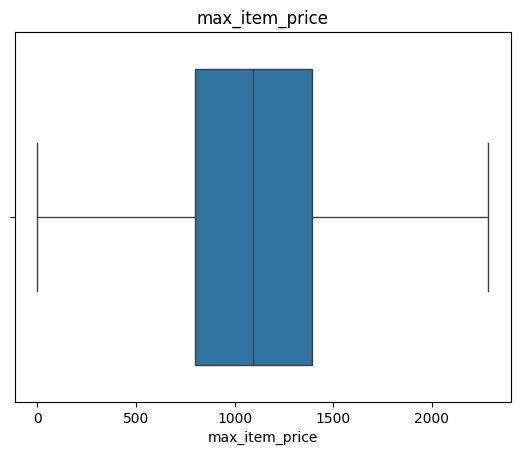

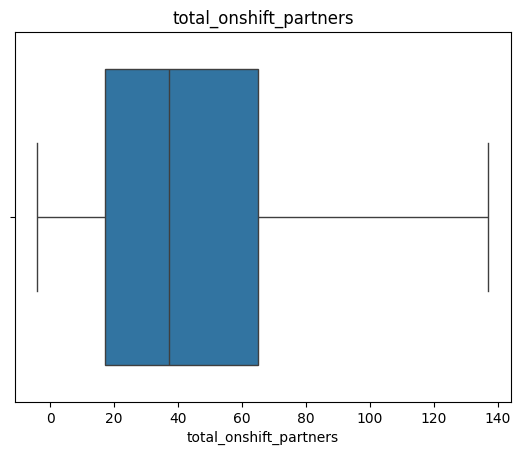

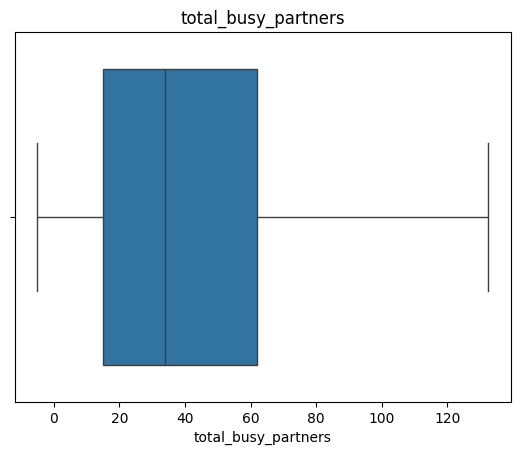

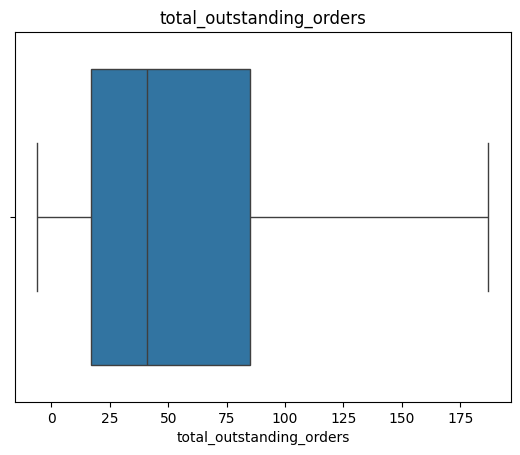

In [73]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Clip = outliers ko remove nahi, unko limit me fix kar deta hai

In [74]:
# time features
df['hour'] = pd.to_datetime(df['created_at']).dt.hour
df['day'] = pd.to_datetime(df['created_at']).dt.dayofweek

# load feature
import numpy as np

df['busy_ratio'] = df['total_busy_partners'] / df['total_onshift_partners']
df['busy_ratio'] = df['busy_ratio'].replace([np.inf, -np.inf], 0)

# price feature
df['price_per_item'] = df['subtotal'] / df['total_items']

creating targeting variable

In [75]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])

df['delivery_time'] = (df['actual_delivery_time'] - df['created_at']).dt.total_seconds()/60

The target variable (delivery_time) was created using timestamp difference. Missing values were handled using appropriate imputation techniques. Categorical features were encoded using one-hot encoding, and numerical features were scaled using standardization.

In [76]:
df = df[df['delivery_time'] > 0]
df = df[df['delivery_time'] < 300]   # realistic range

In [77]:
# categorical
df['store_primary_category'] = df['store_primary_category'].fillna("Unknown")

In [78]:
# mode fill
df['market_id'] = df['market_id'].fillna(df['market_id'].mode()[0])
df['order_protocol'] = df['order_protocol'].fillna(df['order_protocol'].mode()[0])

In [79]:
df['total_onshift_partners'] = df['total_onshift_partners'].fillna(df['total_onshift_partners'].median())
df['total_busy_partners'] = df['total_busy_partners'].fillna(df['total_busy_partners'].median())
df['total_outstanding_orders'] = df['total_outstanding_orders'].fillna(df['total_outstanding_orders'].median())

In [80]:
df.drop(['created_at','actual_delivery_time','store_id'], axis=1, inplace=True)

In [81]:
df.head(3)

,market_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,hour,day,busy_ratio,price_per_item,delivery_time
0,1.0,american,1.0,4,3441.0,4,557,1239.0,33.0,14.0,21.0,22,4,0.424242,860.25,62.983333
1,2.0,mexican,2.0,1,1900.0,1,1400,1400.0,1.0,2.0,2.0,21,1,2.000000,1900.00,67.066667
2,3.0,Unknown,1.0,1,1900.0,1,1900,1900.0,1.0,0.0,0.0,20,3,0.000000,1900.00,29.683333


In [82]:
df = pd.get_dummies(df, columns=[
    'store_primary_category',
    'order_protocol',
    'market_id'
])

In [83]:
df.drop(['busy_ratio', 'price_per_item'], axis=1, inplace=True)

In [84]:
from sklearn.preprocessing import StandardScaler

X = df.drop('delivery_time', axis=1)
y = df['delivery_time']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

A neural network regression model was built using TensorFlow with multiple dense layers and ReLU activation. The model was trained using Adam optimizer and MAE loss function.

In [85]:
from tensorflow.keras.layers import Dropout
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [86]:

model = Sequential([
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mae')

In [87]:

from tensorflow.keras.callbacks import EarlyStopping
early = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,   
    callbacks=[early]
)


Epoch 1/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 12.7931 - val_loss: 11.7964
Epoch 2/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 12.2015 - val_loss: 11.6708
Epoch 3/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 12.1090 - val_loss: 11.6741
Epoch 4/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 12.0242 - val_loss: 11.7454
Epoch 5/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 11.9618 - val_loss: 11.5853
Epoch 6/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 11.8901 - val_loss: 11.5459
Epoch 7/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 11.8601 - val_loss: 11.6513
Epoch 8/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 11.8136 - val_loss: 11.5366
Epoch 9/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 11.7674 - val_loss: 12.0659
Epoch 10/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 11.7403 - val_loss: 11.9448
Epoch 11/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 11.6718 - val_loss: 12.07

In [88]:
y_pred = model.predict(X_test)

1234/1234 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


The model achieved an average error (MAE) of approximately 11–12 minutes. Predictions were reasonably close to actual delivery times, indicating that the model successfully captured the underlying patterns.

In [89]:
model.evaluate(X_test, y_test)

1234/1234 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 11.5022


11.502242088317871

In [90]:
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_test, y_pred))

11.502247965932327


In [91]:
y_pred = model.predict(X_test)

print(y_test[:5])
print(y_pred[:5])

1234/1234 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
20800     48.316667
49839     27.283333
83257     45.200000
115251    37.866667
163211    48.783333
Name: delivery_time, dtype: float64
[[36.084637]
 [29.609837]
 [42.360703]
 [39.66576 ]
 [39.29103 ]]


Insights
Higher number of items → increases delivery time
More busy partners → increases delay
Higher outstanding orders → increases delivery time
Order price and category also impact delivery duration

Increase delivery partners during peak hours
Improve partner allocation system
Use real-time traffic and distance data
Optimize order batching and routing

In [92]:
X.iloc[0].tolist()

[np.int64(4),
 np.float64(3441.0),
 np.int64(4),
 np.int64(557),
 np.float64(1239.0),
 np.float64(33.0),
 np.float64(14.0),
 np.float64(21.0),
 np.int32(22),
 np.int32(4),
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.True_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 

In [94]:
import pickle
# 1. scaler save
pickle.dump(scaler, open("scaler.pkl", "wb"))
# 2. model save 
model.save("model.keras")  
# 3. columns save 
pickle.dump(X.columns.tolist(), open("cols.pkl", "wb"))
print("All files saved successfully")

All files saved successfully


In [35]:
# # load karke test
# import pickle
# from tensorflow.keras.models import load_model

# scaler = pickle.load(open("scaler.pkl", "rb"))
# model = load_model("model.h5")
# cols = pickle.load(open("cols.pkl", "rb"))

# print("✅ Sab load ho gaya")

✅ Sab load ho gaya


In [ ]:
[np.int64(4),
 np.float64(3441.0),
 np.int64(4),
 np.int64(557),
 np.float64(1239.0),
 np.float64(33.0),
 np.float64(14.0),
 np.float64(21.0),
 np.int32(22),
 np.int32(4),

In [ ]:
# import streamlit as st
# import numpy as np
# import pandas as pd
# import pickle
# from tensorflow.keras.models import load_model

# # Load files
# scaler = pickle.load(open("scaler.pkl", "rb"))
# model = load_model("model.h5")
# cols = pickle.load(open("cols.pkl", "rb"))

# st.title("🚚 Delivery Time Predictor")
# st.write("Fill in the order details to predict delivery time:")

# # --- Raw Inputs ---
# st.subheader("📦 Order Info")
# total_items = st.number_input("Total Items", min_value=1, max_value=50, value=3)
# subtotal = st.number_input("Subtotal (Rs)", min_value=0.0, max_value=10000.0, value=2000.0)
# num_distinct_items = st.number_input("Num Distinct Items", min_value=1, max_value=50, value=3)
# min_item_price = st.number_input("Min Item Price", min_value=0.0, max_value=5000.0, value=200.0)
# max_item_price = st.number_input("Max Item Price", min_value=0.0, max_value=5000.0, value=800.0)

# st.subheader("🛵 Partner Info")
# total_onshift_partners = st.number_input("Total Onshift Partners", min_value=0.0, max_value=100.0, value=10.0)
# total_busy_partners = st.number_input("Total Busy Partners", min_value=0.0, max_value=100.0, value=5.0)
# total_outstanding_orders = st.number_input("Total Outstanding Orders", min_value=0.0, max_value=100.0, value=5.0)

# st.subheader("🕐 Time Info")
# hour = st.slider("Order Hour (0-23)", min_value=0, max_value=23, value=12)
# day = st.slider("Day of Week (0=Mon, 6=Sun)", min_value=0, max_value=6, value=2)

# st.subheader("🏪 Restaurant Info")
# categories = ['afghan', 'african', 'alcohol', 'alcohol-plus-food', 'american',
#               'argentine', 'asian', 'barbecue', 'belgian', 'brazilian', 'breakfast',
#               'british', 'bubble-tea', 'burger', 'burmese', 'cafe', 'cajun',
#               'caribbean', 'catering', 'cheese', 'chinese', 'chocolate', 'comfort-food',
#               'convenience-store', 'dessert', 'dim-sum', 'ethiopian', 'european',
#               'fast', 'filipino', 'french', 'gastropub', 'german', 'gluten-free',
#               'greek', 'hawaiian', 'indian', 'indonesian', 'irish', 'italian',
#               'japanese', 'korean', 'kosher', 'latin-american', 'lebanese', 'malaysian',
#               'mediterranean', 'mexican', 'middle-eastern', 'moroccan', 'nepalese',
#               'other', 'pakistani', 'pasta', 'persian', 'peruvian', 'pizza', 'russian',
#               'salad', 'sandwich', 'seafood', 'singaporean', 'smoothie', 'soup',
#               'southern', 'spanish', 'steak', 'sushi', 'tapas', 'thai', 'turkish',
#               'vegan', 'vegetarian', 'vietnamese']

# store_primary_category = st.selectbox("Store Category", categories)
# market_id = st.selectbox("Market ID", [1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
# order_protocol = st.selectbox("Order Protocol", [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0])

# # --- Predict Button ---
# if st.button("🔮 Predict Delivery Time"):

#     # Step 1: Raw data dict banao
#     input_dict = {
#         'total_items': total_items,
#         'subtotal': subtotal,
#         'num_distinct_items': num_distinct_items,
#         'min_item_price': min_item_price,
#         'max_item_price': max_item_price,
#         'total_onshift_partners': total_onshift_partners,
#         'total_busy_partners': total_busy_partners,
#         'total_outstanding_orders': total_outstanding_orders,
#         'hour': hour,
#         'day': day,
#         'store_primary_category': store_primary_category,
#         'market_id': market_id,
#         'order_protocol': order_protocol,
#     }

#     # Step 2: DataFrame banao
#     input_df = pd.DataFrame([input_dict])

#     # Step 3: One-hot encoding (same as training)
#     input_df = pd.get_dummies(input_df, columns=[
#         'store_primary_category',
#         'order_protocol',
#         'market_id'
#     ])

#     # Step 4: Missing cols add karo (jo training mein the but input mein nahi)
#     for col in cols:
#         if col not in input_df.columns:
#             input_df[col] = 0

#     # Step 5: Columns ka order same rakho
#     input_df = input_df[cols]

#     # Step 6: Scale karo
#     input_scaled = scaler.transform(input_df)

#     # Step 7: Predict karo
#     pred = model.predict(input_scaled)

#     st.success(f"⏱️ Predicted Delivery Time: **{pred[0][0]:.1f} minutes**")